In [4]:
# Smart Marketing Prediction System (ML Pipeline Project)

# Scenario
# A fast-growing e-commerce company called ShopEasy is struggling with inefficient marketing campaigns.

# Every day thousands of users visit their website. The marketing team spends a large amount of money showing ads, discounts, and promotional emails, but they don't know which customers are actually likely to buy something.

# Currently:

# Many customers browse but never purchase

# Marketing money is wasted on the wrong users

# The company wants to predict purchase probability

# The data science team has been asked to build a machine learning system that predicts whether a customer will purchase a product during a session.

# If the system predicts high probability of purchase, the system will:

# show personalized product recommendations

# offer targeted discounts

# prioritize marketing campaigns

# If the system predicts low probability, the company will avoid spending marketing resources.

# However, the dataset contains both numerical and categorical features, so the data science team must design a complete ML pipeline.

# Dataset is available in DatasetCapstoneProject3 in the github repo link https://github.com/himanshusar123/Datasets

# Business Objective
# Build a machine learning model that predicts whether a user will purchase (1) or not purchase (0) during a website session.

# The model must be implemented using scikit-learn pipelines, including:

# Encoding techniques

# Feature preprocessing

# Model training

# Model selection

# Hyperparameter tuning

# /content/DatasetCapstoneProject3.xlsx is the dataset


   CustomerID  Age  Gender   Device  Traffic_Source  Time_on_Website  \
0           1   23    Male   Mobile    Social Media                5   
1           2   35  Female  Desktop   Search Engine               12   
2           3   29    Male   Tablet    Social Media                8   
3           4   41  Female   Mobile  Email Campaign               15   
4           5   22  Female  Desktop          Direct                4   

   Pages_Visited  Ad_Clicks  Previous_Purchases  Purchased  
0              3          1                   0          0  
1              8          3                   2          1  
2              5          2                   1          0  
3             10          4                   3          1  
4              2          0                   0          0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0

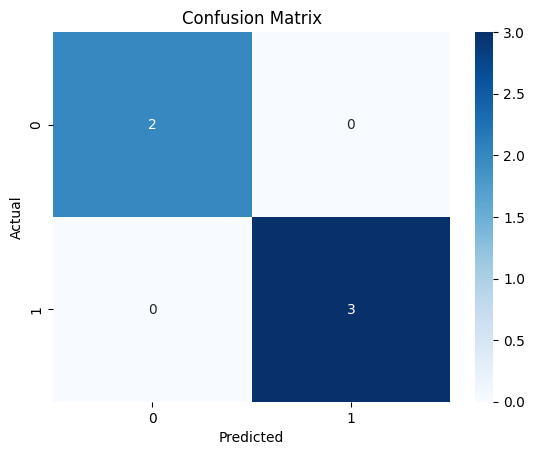


Purchase Probabilities: [[0.65958306 0.34041694]
 [0.37856159 0.62143841]
 [0.69809773 0.30190227]
 [0.16770601 0.83229399]
 [0.13126742 0.86873258]]

Marketing Decision:
Customer 0 Low purchase probability,hence No Marketing Spend
Customer 1 Low purchase probability,hence No Marketing Spend
Customer 2 Low purchase probability,hence No Marketing Spend
Customer 3 High purchase probability,hence Offer Discount
Customer 4 High purchase probability,hence Offer Discount


In [7]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Load Dataset
df = pd.read_excel("/content/DatasetCapstoneProject3.xlsx")
print(df.head())

# 3. Dataset Information
print(df.info())
print(df.describe())

# 4. Check Missing Values
print(df.isnull().sum())

# 5. Drop CustomerID (not useful for prediction)
df = df.drop("CustomerID", axis=1)

# 6. Define Features and Target
X = df.drop("Purchased", axis=1)
y = df["Purchased"]

# 7. Define Numerical and Categorical Columns
num_features = [
    "Age",
    "Time_on_Website",
    "Pages_Visited",
    "Ad_Clicks",
    "Previous_Purchases"
]
cat_features = [
    "Gender",
    "Device",
    "Traffic_Source"
]

# 8. Create Preprocessing Pipelines
# Numerical pipeline
num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine pipelines
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

# 9. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.3,
    random_state=42
)

# 10. Create ML Pipeline
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression())
])

# 11. Hyperparameter Tuning using GridSearchCV
param_grid = {
    "model__C": [0.01,0.1,1,10],
    "model__solver": ["lbfgs"]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="accuracy"
)

# 12. Train Model with Hyperparameter Tuning
grid_search.fit(X_train,y_train)

# Best Model
best_model = grid_search.best_estimator_
print("\nBest Parameters:",grid_search.best_params_)

# 13.Predictions
y_pred = best_model.predict(X_test)

# 14. Model Evaluation
print("\nModel Accuracy:",accuracy_score(y_test, y_pred))
print("\nClassification Report:",classification_report(y_test, y_pred))

# 15. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 16. Predict Purchase Probability
probabilities = best_model.predict_proba(X_test)
print("\nPurchase Probabilities:",probabilities)

# 17. Marketing Decision Example
purchase_prob = probabilities[:,1]
print("\nMarketing Decision:")
for i, prob in enumerate(purchase_prob):
    if prob > 0.7:
        print("Customer", i, "High purchase probability,hence Offer Discount")
    else:
        print("Customer", i, "Low purchase probability,hence No Marketing Spend")